## importing modules


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## data collection and preprocessing

In [2]:
data=pd.read_csv('datasets/Pokemon.csv')

In [3]:
data

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [4]:
df=data.drop(['Name','#','Type 1','Type 2'],axis=1)

In [5]:
df

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,318,45,49,49,65,65,45,1,False
1,405,60,62,63,80,80,60,1,False
2,525,80,82,83,100,100,80,1,False
3,625,80,100,123,122,120,80,1,False
4,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...
795,600,50,100,150,100,150,50,6,True
796,700,50,160,110,160,110,110,6,True
797,600,80,110,60,150,130,70,6,True
798,680,80,160,60,170,130,80,6,True


In [6]:
# Check the data type and unique values
print("Data type:", df['Legendary'].dtype)
print("Unique values:", df['Legendary'].unique())
print("Value counts:", df['Legendary'].value_counts())

Data type: bool
Unique values: [False  True]
Value counts: Legendary
False    735
True      65
Name: count, dtype: int64


In [7]:
df.replace({'Legendary':{False:0, True:1}}, inplace=True)

/var/folders/8k/380c1z1n5xj7p7vqw290h7v80000gn/T/ipykernel_72536/2049119638.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Legendary':{False:0, True:1}}, inplace=True)


In [8]:
df

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,318,45,49,49,65,65,45,1,0
1,405,60,62,63,80,80,60,1,0
2,525,80,82,83,100,100,80,1,0
3,625,80,100,123,122,120,80,1,0
4,309,39,52,43,60,50,65,1,0
...,...,...,...,...,...,...,...,...,...
795,600,50,100,150,100,150,50,6,1
796,700,50,160,110,160,110,110,6,1
797,600,80,110,60,150,130,70,6,1
798,680,80,160,60,170,130,80,6,1


## spliting of data into train and test data

In [9]:
X = df.drop('Legendary',axis=1)
Y= df['Legendary']

## visualizing data

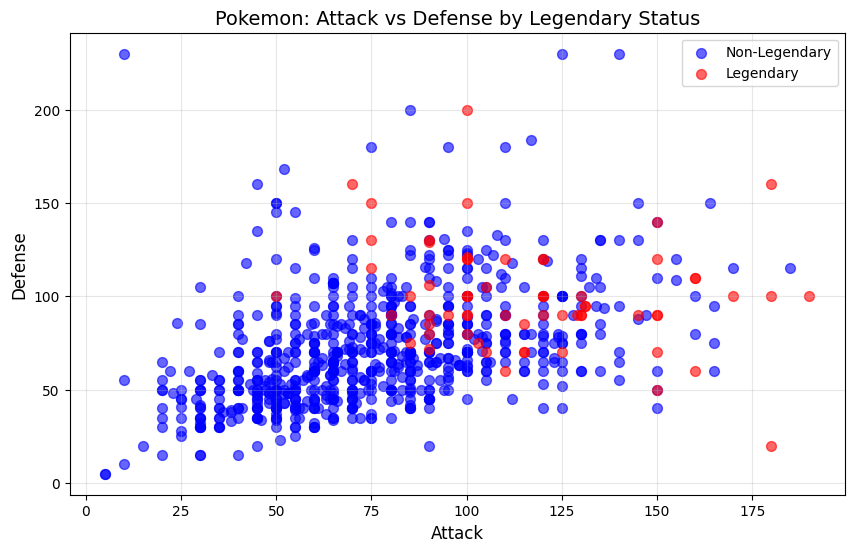

In [10]:
# Option 1: Scatter plot - Attack vs Defense
plt.figure(figsize=(10, 6))
plt.scatter(X['Attack'][Y==0], X['Defense'][Y==0], alpha=0.6, label='Non-Legendary', c='blue', s=50)
plt.scatter(X['Attack'][Y==1], X['Defense'][Y==1], alpha=0.6, label='Legendary', c='red', s=50)
plt.xlabel('Attack', fontsize=12)
plt.ylabel('Defense', fontsize=12)
plt.title('Pokemon: Attack vs Defense by Legendary Status', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

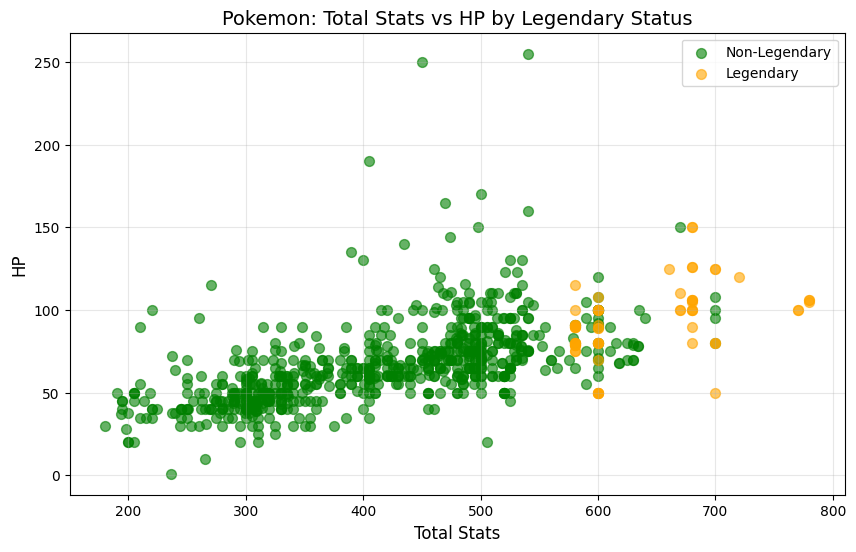

In [11]:
# Option 2: Scatter plot - Total Stats vs HP
plt.figure(figsize=(10, 6))
plt.scatter(X['Total'][Y==0], X['HP'][Y==0], alpha=0.6, label='Non-Legendary', c='green', s=50)
plt.scatter(X['Total'][Y==1], X['HP'][Y==1], alpha=0.6, label='Legendary', c='orange', s=50)
plt.xlabel('Total Stats', fontsize=12)
plt.ylabel('HP', fontsize=12)
plt.title('Pokemon: Total Stats vs HP by Legendary Status', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

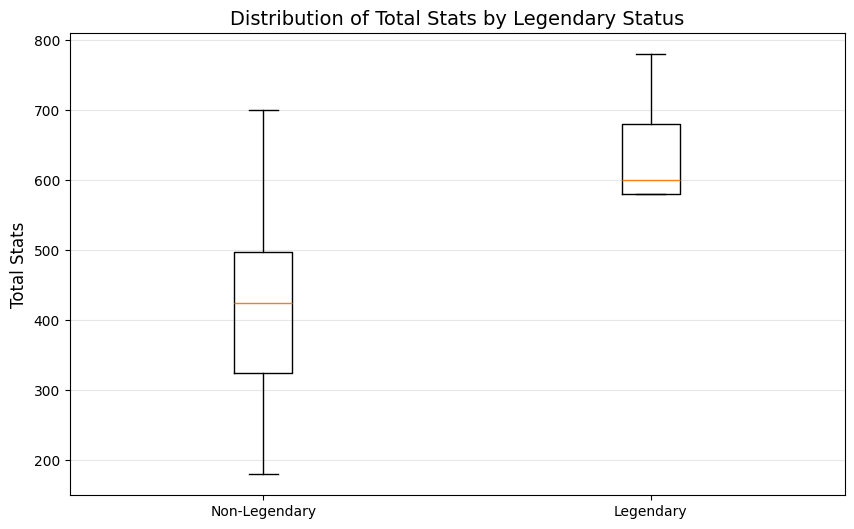

In [12]:
# Option 3: Box plot - Distribution of Total Stats
plt.figure(figsize=(10, 6))
legendary_stats = X[Y==1]['Total']
non_legendary_stats = X[Y==0]['Total']
plt.boxplot([non_legendary_stats, legendary_stats], tick_labels=['Non-Legendary', 'Legendary'])
plt.ylabel('Total Stats', fontsize=12)
plt.title('Distribution of Total Stats by Legendary Status', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## splitting data

In [13]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y, random_state=2,test_size=0.2,stratify=Y)

## model training

In [14]:
model= LogisticRegression()

In [15]:
model.fit(X_train,Y_train)

/Users/kishan/.pyenv/versions/3.11.14/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## model accuracy

In [16]:
X_train_prediction=model.predict(X_train)
X_train_prediction_accuracy= accuracy_score(X_train_prediction,Y_train)

In [17]:
X_train_prediction_accuracy

0.95

In [18]:
X_test_prediction= model.predict(X_test)
X_test_prediction_accuracy= accuracy_score(Y_test,X_test_prediction)

In [19]:
X_test_prediction_accuracy

0.95625